In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [42]:
df= pd.read_csv('../datasets/kentucky_real_estate.csv')

df.head()

,type,sub_type,text,listPrice,sqft,stories,beds,baths,baths_full,baths_full_calc,garage,year_built
0,single_family,NaN,Welcome to this beautifully maintained ranch h...,550000.0,3460.0,2.0,6.0,4.0,4.0,4.0,2.0,2003.0
1,single_family,NaN,New construction by Fischer Homes in the beaut...,501029.0,3146.0,2.0,4.0,3.0,2.0,2.0,2.0,2026.0
2,single_family,NaN,"Beautiful 5-bedroom, 4.5-bath home located in ...",859990.0,3918.0,2.0,5.0,5.0,4.0,4.0,2.0,2023.0
3,single_family,NaN,If you're looking for convenient living on one...,537100.0,1987.0,1.0,2.0,NaN,2.0,2.0,2.0,NaN
4,single_family,NaN,This beautiful ranch home with a basement is l...,339900.0,3200.0,1.0,5.0,3.0,3.0,3.0,2.0,NaN


# EDA

In [43]:
df.shape

(8502, 12)

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8502 entries, 0 to 8501
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   type             8502 non-null   object 
 1   sub_type         535 non-null    object 
 2   text             8380 non-null   object 
 3   listPrice        8487 non-null   float64
 4   sqft             7868 non-null   float64
 5   stories          6708 non-null   float64
 6   beds             8097 non-null   float64
 7   baths            7804 non-null   float64
 8   baths_full       7997 non-null   float64
 9   baths_full_calc  8002 non-null   float64
 10  garage           5605 non-null   float64
 11  year_built       6741 non-null   float64
dtypes: float64(9), object(3)
memory usage: 797.2+ KB


In [45]:
df.describe()

,listPrice,sqft,stories,beds,baths,baths_full,baths_full_calc,garage,year_built
count,8.487000e+03,7868.000000,6708.000000,8097.000000,7804.000000,7997.000000,8002.000000,5605.000000,6741.000000
mean,3.914692e+05,2150.625953,1.535033,3.327158,2.426064,2.113918,2.114846,11.912043,1992.965287
std,4.105916e+05,1335.424356,0.556187,1.400185,1.251852,0.972690,0.972658,708.711176,35.021180
min,1.000000e+00,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1784.000000
25%,2.200000e+05,1377.000000,1.000000,3.000000,2.000000,2.000000,2.000000,2.000000,1972.000000
50%,3.179000e+05,1850.000000,2.000000,3.000000,2.000000,2.000000,2.000000,2.000000,2003.000000
75%,4.500000e+05,2600.000000,2.000000,4.000000,3.000000,2.000000,2.000000,2.000000,2024.000000
max,2.000000e+07,42686.000000,6.000000,41.000000,30.000000,30.000000,30.000000,53050.000000,2027.000000


In [46]:
# drop duplicated



In [47]:
df.duplicated().sum()

np.int64(49)

In [48]:
# separate num null cols and categorical cols

num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

In [49]:
df.columns

Index(['type', 'sub_type', 'text', 'listPrice', 'sqft', 'stories', 'beds',
       'baths', 'baths_full', 'baths_full_calc', 'garage', 'year_built'],
      dtype='object')

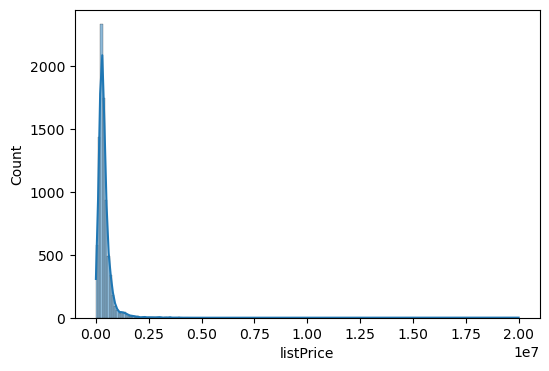

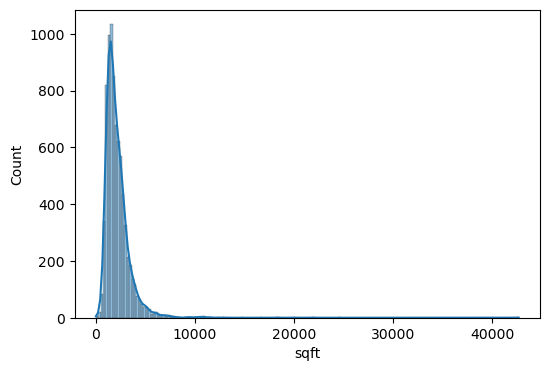

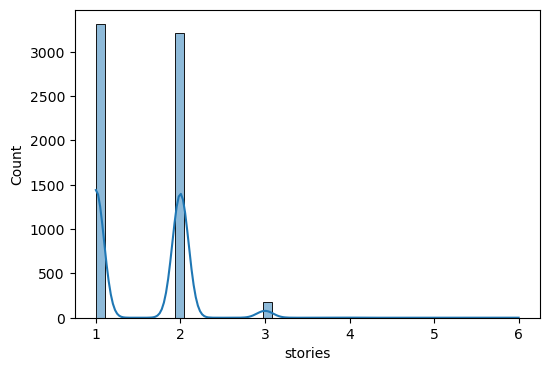

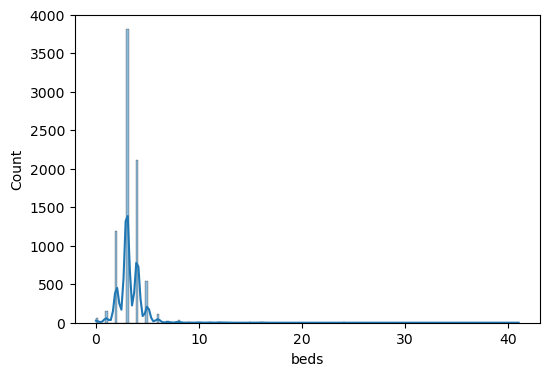

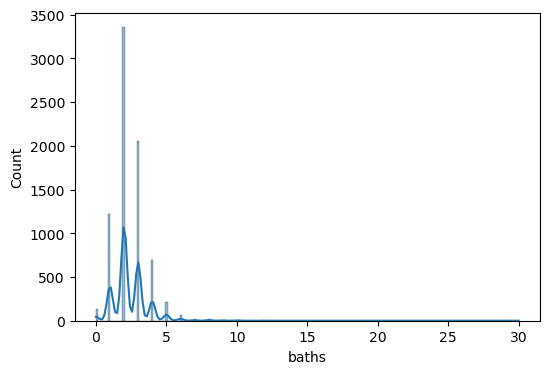

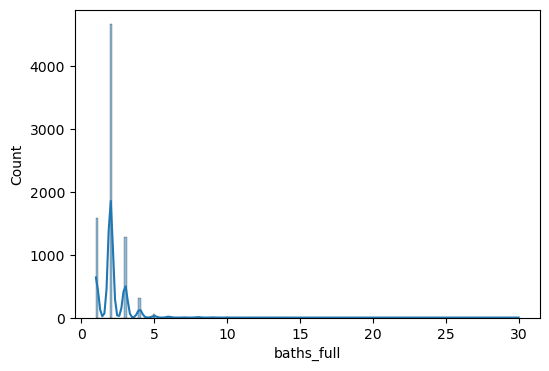

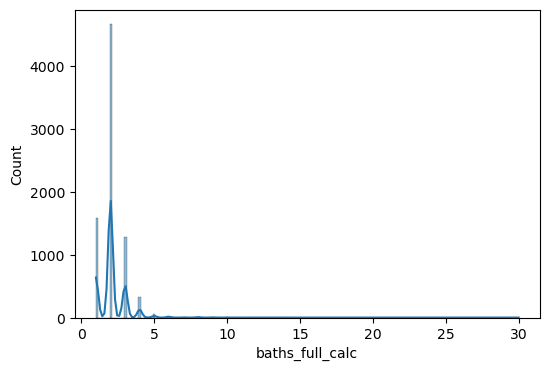

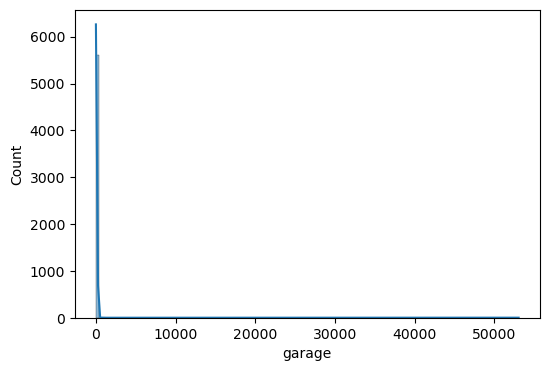

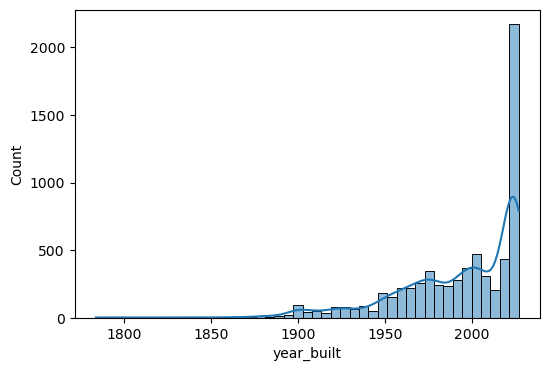

In [50]:

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df,x=df[col],kde=True)

<Axes: xlabel='type'>

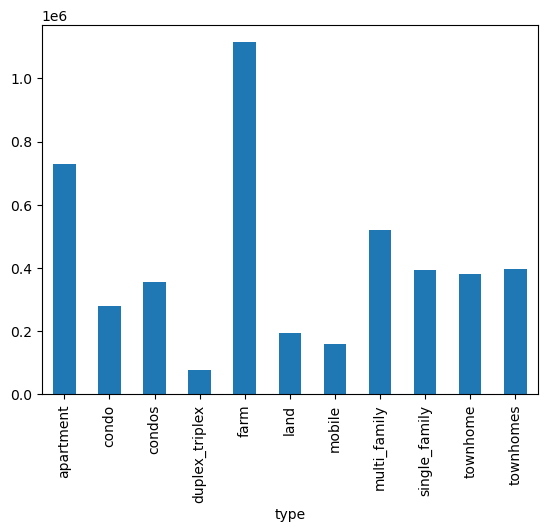

In [51]:
df.groupby(['type'])['listPrice'].mean().plot(kind='bar')

<Axes: xlabel='type'>

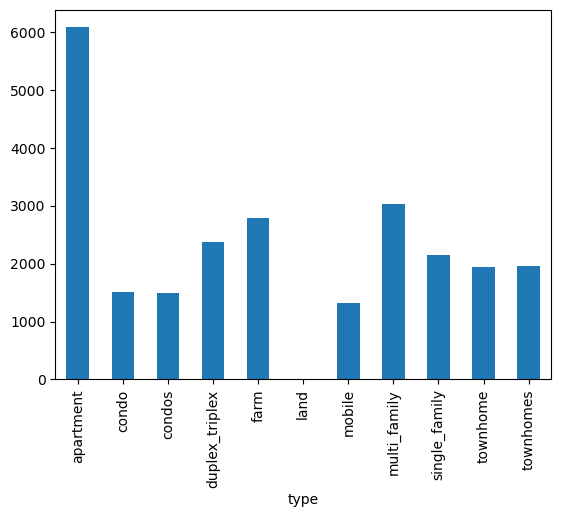

In [52]:
df.groupby(['type'])['sqft'].mean().plot(kind='bar')

In [53]:
df.head()

,type,sub_type,text,listPrice,sqft,stories,beds,baths,baths_full,baths_full_calc,garage,year_built
0,single_family,NaN,Welcome to this beautifully maintained ranch h...,550000.0,3460.0,2.0,6.0,4.0,4.0,4.0,2.0,2003.0
1,single_family,NaN,New construction by Fischer Homes in the beaut...,501029.0,3146.0,2.0,4.0,3.0,2.0,2.0,2.0,2026.0
2,single_family,NaN,"Beautiful 5-bedroom, 4.5-bath home located in ...",859990.0,3918.0,2.0,5.0,5.0,4.0,4.0,2.0,2023.0
3,single_family,NaN,If you're looking for convenient living on one...,537100.0,1987.0,1.0,2.0,NaN,2.0,2.0,2.0,NaN
4,single_family,NaN,This beautiful ranch home with a basement is l...,339900.0,3200.0,1.0,5.0,3.0,3.0,3.0,2.0,NaN


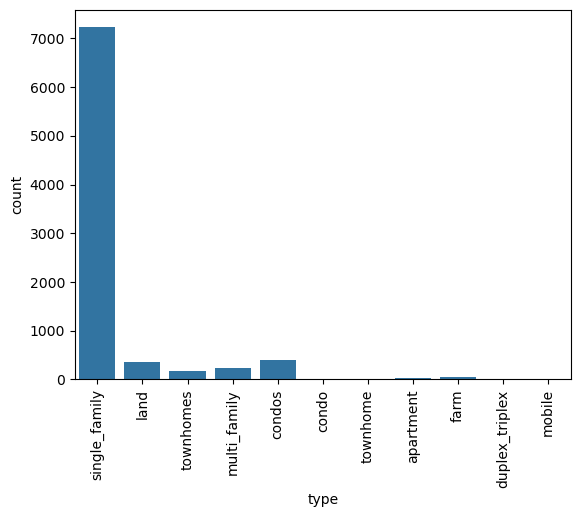

In [54]:
sns.countplot(df,x=df['type'])
plt.xticks(rotation=90)
plt.show()

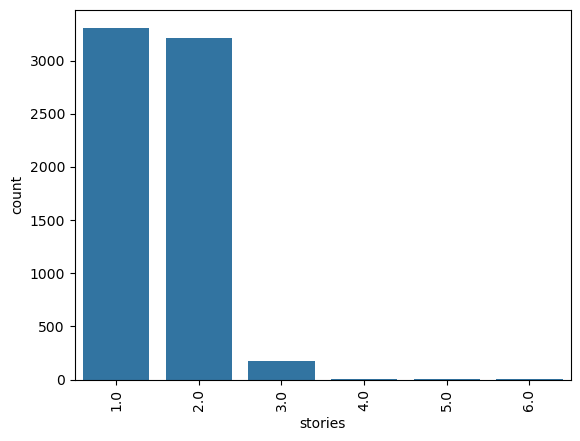

In [55]:
sns.countplot(df,x=df['stories'])
plt.xticks(rotation=90)
plt.show()

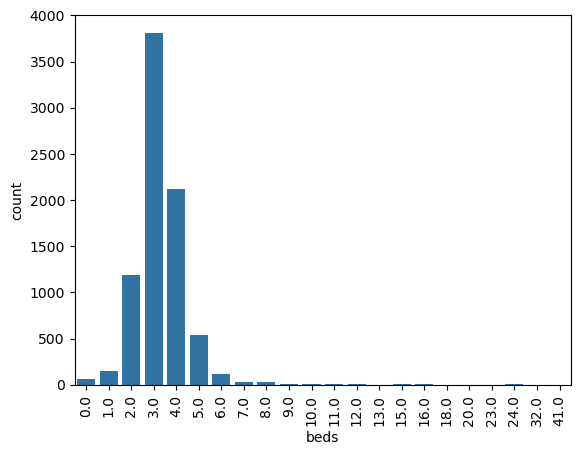

In [56]:
sns.countplot(df,x=df['beds'])
plt.xticks(rotation=90)
plt.show()

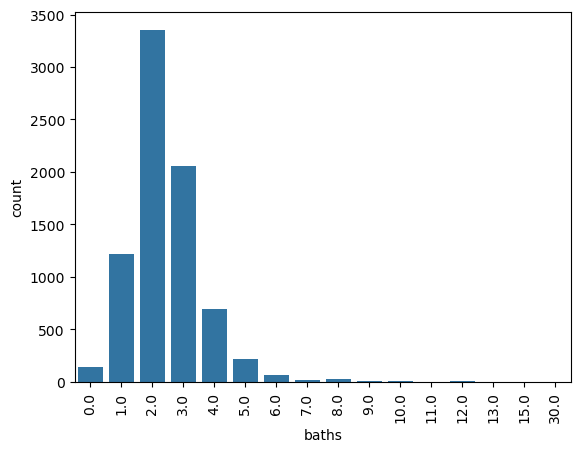

In [57]:
sns.countplot(df,x=df['baths'])
plt.xticks(rotation=90)
plt.show()

<Axes: xlabel='garage'>

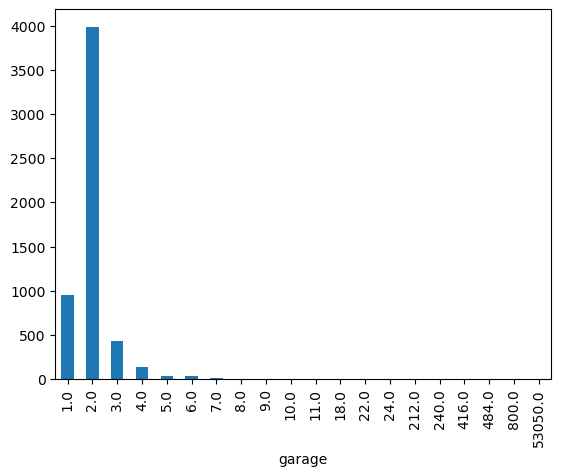

In [58]:
df.groupby(['garage'])['listPrice'].count().plot(kind='bar')

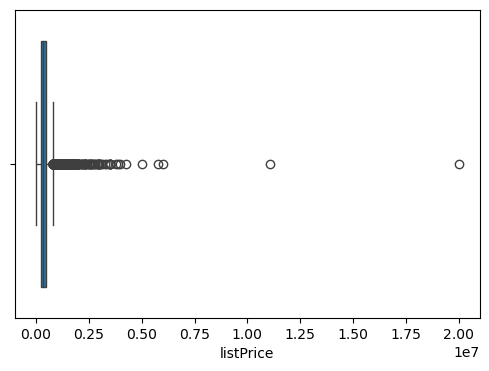

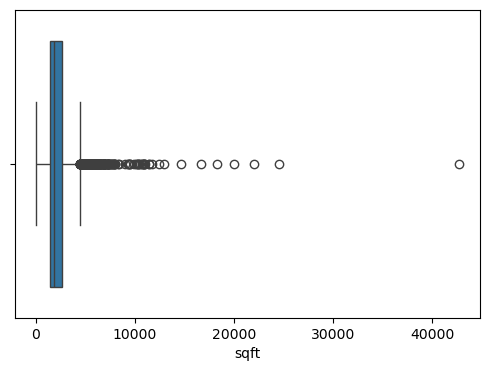

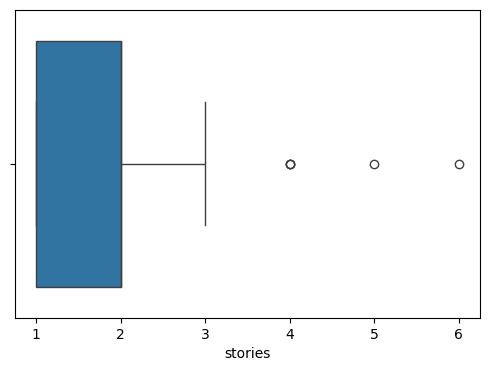

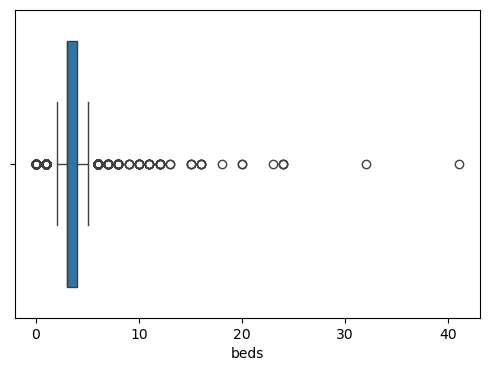

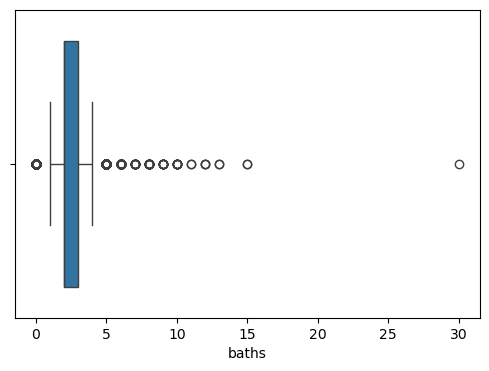

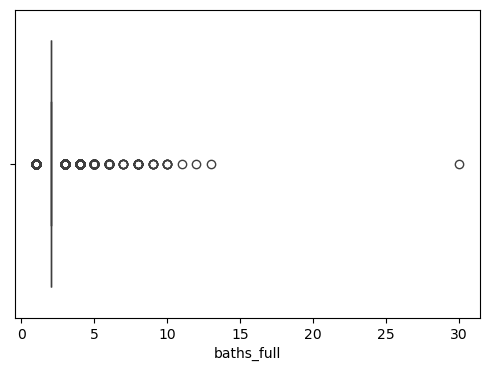

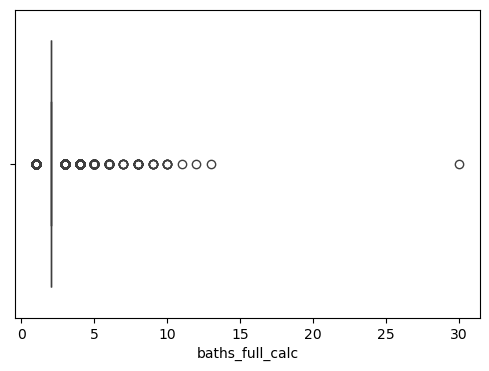

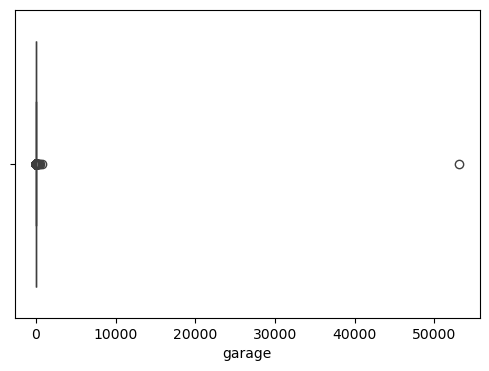

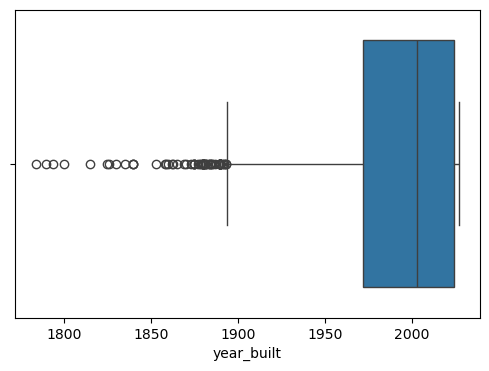

In [59]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(df,x=df[col])

<Axes: >

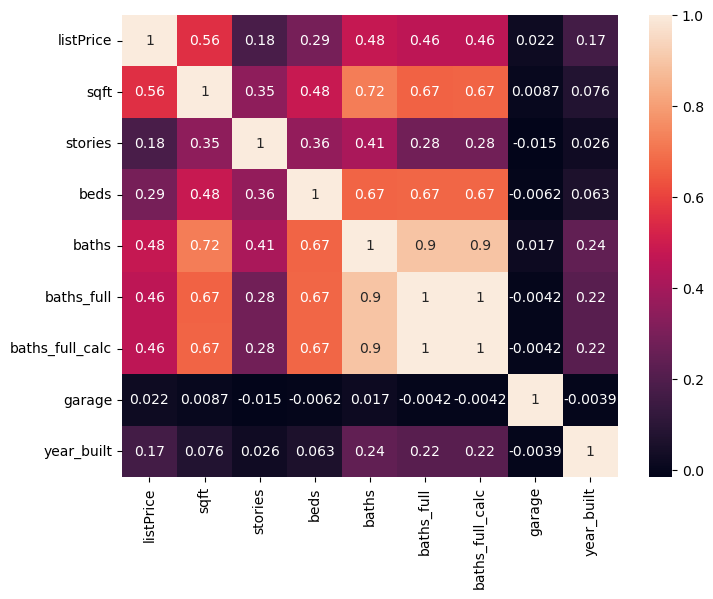

In [60]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),annot=True)

# Data Cleaning and Pre-Processing

In [61]:

df_cleaned=df.copy()

print(df_cleaned.isnull().sum()[df_cleaned.isnull().sum() > 0])

sub_type           7967
text                122
listPrice            15
sqft                634
stories            1794
beds                405
baths               698
baths_full          505
baths_full_calc     500
garage             2897
year_built         1761
dtype: int64


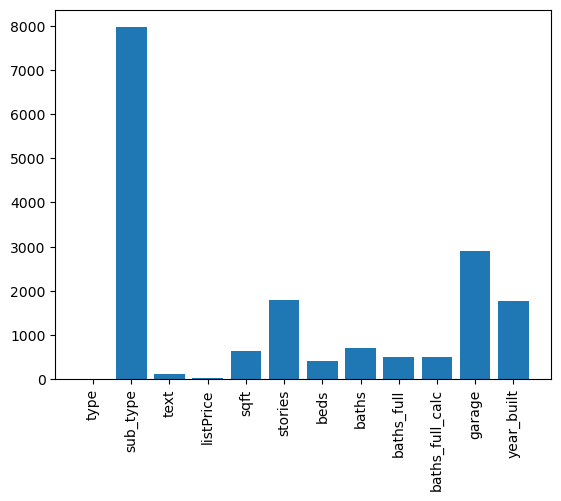

In [62]:
plt.bar(df_cleaned.columns, df_cleaned.isnull().sum())
plt.xticks(rotation=90)
plt.show()

In [63]:
df_cleaned[df_cleaned.duplicated()].head()

,type,sub_type,text,listPrice,sqft,stories,beds,baths,baths_full,baths_full_calc,garage,year_built
571,townhomes,townhouse,New construction 3 bed 2.5 bath townhouse with...,266500.0,1778.0,NaN,3.0,3.0,2.0,2.0,1.0,2026.0
2127,townhomes,townhouse,"Welcome to the highly sought-after, upscale ne...",349000.0,2027.0,NaN,3.0,3.0,2.0,2.0,1.0,2025.0
2186,single_family,NaN,Attention Investors! Don't miss out on this op...,900000.0,978.0,1.0,3.0,1.0,1.0,1.0,NaN,1997.0
2467,condos,condo,The Boardwalk Residences at Ovation feature 88...,2320000.0,NaN,1.0,2.0,2.0,2.0,2.0,1.0,2023.0
2899,condos,condo,The Boardwalk Residences at Ovation are locate...,1095000.0,NaN,1.0,2.0,2.0,2.0,2.0,1.0,2023.0


In [64]:
df_cleaned = df_cleaned.drop_duplicates()

In [65]:
# separate num null cols and categorical cols

num_cols = df_cleaned.select_dtypes(include=['int64','float64']).columns
cat_cols = df_cleaned.select_dtypes(include=['object']).columns

In [66]:
df_cleaned[num_cols] = df_cleaned[num_cols].fillna(df[num_cols].median())
df_cleaned[cat_cols] = df_cleaned[cat_cols].fillna("Unknown")

In [67]:
df_cleaned.head()

,type,sub_type,text,listPrice,sqft,stories,beds,baths,baths_full,baths_full_calc,garage,year_built
0,single_family,Unknown,Welcome to this beautifully maintained ranch h...,550000.0,3460.0,2.0,6.0,4.0,4.0,4.0,2.0,2003.0
1,single_family,Unknown,New construction by Fischer Homes in the beaut...,501029.0,3146.0,2.0,4.0,3.0,2.0,2.0,2.0,2026.0
2,single_family,Unknown,"Beautiful 5-bedroom, 4.5-bath home located in ...",859990.0,3918.0,2.0,5.0,5.0,4.0,4.0,2.0,2023.0
3,single_family,Unknown,If you're looking for convenient living on one...,537100.0,1987.0,1.0,2.0,2.0,2.0,2.0,2.0,2003.0
4,single_family,Unknown,This beautiful ranch home with a basement is l...,339900.0,3200.0,1.0,5.0,3.0,3.0,3.0,2.0,2003.0


In [68]:
df_cleaned.shape

(8453, 12)

In [69]:
df_cleaned.loc[0, 'text']

"Welcome to this beautifully maintained ranch home nestled in the desirable Nature Cove neighborhood of Mt Washington, offering over 3, 400 square feet of finished living space designed for comfort, flexibility, and entertaining. Situated on a spacious 0.64-acre lot, this 6-bedroom, 4-bath home provides the perfect blend of indoor and outdoor living. The fenced backyard offers plenty of room to roam, play, garden, or simply relax and enjoy the peaceful surroundings. Step inside through the foyer and immediately notice the inviting living room featuring a vaulted ceiling and a stunning fireplace that creates a warm and cozy focal point. Just off the living room, a door leads to a raised deck overlooking the expansive backyard - ideal for morning coffee or evening gatherings. The open flow between the living and dining rooms makes hosting friends and family effortless. The eat-in kitchen offers a charming breakfast nook and a convenient peninsula with counter seating, perfect for quick m

In [70]:
#removed unnecessery data cols

df_cleaned.drop(columns=['text','sub_type','baths_full_calc'],inplace=True)

In [71]:
df_cleaned.head()

,type,listPrice,sqft,stories,beds,baths,baths_full,garage,year_built
0,single_family,550000.0,3460.0,2.0,6.0,4.0,4.0,2.0,2003.0
1,single_family,501029.0,3146.0,2.0,4.0,3.0,2.0,2.0,2026.0
2,single_family,859990.0,3918.0,2.0,5.0,5.0,4.0,2.0,2023.0
3,single_family,537100.0,1987.0,1.0,2.0,2.0,2.0,2.0,2003.0
4,single_family,339900.0,3200.0,1.0,5.0,3.0,3.0,2.0,2003.0


In [72]:
df_cleaned['type'].value_counts()

type
single_family     7201
condos             381
land               356
multi_family       230
townhomes          169
farm                46
apartment           20
mobile              18
condo               17
townhome            12
duplex_triplex       3
Name: count, dtype: int64

In [73]:
# clean categorys data names

df_cleaned['type'] = df_cleaned['type'].replace({
    'condos': 'condo',
    'townhomes': 'townhome'
})

In [74]:
type_counts = df_cleaned['type'].value_counts()

rare_types = type_counts[type_counts < 50].index

df_cleaned['type'] = df_cleaned['type'].replace(rare_types, 'other')

In [75]:
# covert categorical columns into numeric values

In [76]:
#one hot encoding
df_cleaned['type'].value_counts()

type
single_family    7201
condo             398
land              356
multi_family      230
townhome          181
other              87
Name: count, dtype: int64

In [77]:
df_cleaned = pd.get_dummies(df_cleaned, columns=['type'], drop_first=True, dtype=int)

In [78]:
df_cleaned.head()

,listPrice,sqft,stories,beds,baths,baths_full,garage,year_built,type_land,type_multi_family,type_other,type_single_family,type_townhome
0,550000.0,3460.0,2.0,6.0,4.0,4.0,2.0,2003.0,0,0,0,1,0
1,501029.0,3146.0,2.0,4.0,3.0,2.0,2.0,2026.0,0,0,0,1,0
2,859990.0,3918.0,2.0,5.0,5.0,4.0,2.0,2023.0,0,0,0,1,0
3,537100.0,1987.0,1.0,2.0,2.0,2.0,2.0,2003.0,0,0,0,1,0
4,339900.0,3200.0,1.0,5.0,3.0,3.0,2.0,2003.0,0,0,0,1,0


In [79]:
df_cleaned=df_cleaned.astype(int)

In [80]:
df_cleaned.head()

,listPrice,sqft,stories,beds,baths,baths_full,garage,year_built,type_land,type_multi_family,type_other,type_single_family,type_townhome
0,550000,3460,2,6,4,4,2,2003,0,0,0,1,0
1,501029,3146,2,4,3,2,2,2026,0,0,0,1,0
2,859990,3918,2,5,5,4,2,2023,0,0,0,1,0
3,537100,1987,1,2,2,2,2,2003,0,0,0,1,0
4,339900,3200,1,5,3,3,2,2003,0,0,0,1,0
